# Anagrelide as a PDE3A-SLFN12 Molecular Glue: A Structure-Activity and Descriptor Analysis

**Research question:** Can the structure-activity relationships of the
anagrelide molecular-glue series be quantitatively verified and extended
using RDKit descriptors, and do they structurally distinguish this class
from classical (non-glue) PDE3A inhibitors?

**Data source:** Chen et al., *Nature Communications* 2021, 12:6204
(PMC8551160), Supplementary Table 2 (22 anagrelide analogs + anagrelide
itself, with measured IC50 against PDE3A-SLFN12-dependent apoptosis).

**Motivation:** Anagrelide is one of a small number of structurally
characterized molecular glues, with a real cryo-EM structure available
(PDB 7EG0). This makes it a rare case where 2D descriptor-based
hemoinformatics can be directly cross-checked against 3D experimental
structure.

In [4]:
import sys
sys.path.append('../scripts')
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

## Dataset: Molecular Glue Analogs (Anagrelide + 22 analogs)

In [5]:
df_glue = pd.read_csv('../data/anagrelide_analogs.csv')
df_glue[['compound', 'smiles', 'formula', 'rdkit_logp', 'ic50_nM', 'paper_logp']]

,compound,smiles,formula,rdkit_logp,ic50_nM,paper_logp
0,Anagrelide,O=C1CN2Cc3c(ccc(Cl)c3Cl)NC2=N1,C10H7Cl2N3O,2.12,6.67,2.08
1,A1,O=C1CN2Cc3c(ccc(Cl)c3Br)NC2=N1,C10H7BrClN3O,2.23,2.50,2.36
2,A2,O=C1CN2Cc3c(ccc(Cl)c3F)NC2=N1,C10H7ClFN3O,1.60,34.20,1.68
3,A3,C=Cc1c(Cl)ccc2c1CN1CC(=O)N=C1N2,C12H10ClN3O,2.11,10.40,2.16
4,A4,O=C1CN2Cc3c(ccc(Cl)c3-c3ccccc3)NC2=N1,C16H12ClN3O,3.13,0.56,3.20
5,A5,O=C1CN2Cc3c(cc(Cl)c(Cl)c3Cl)NC2=N1,C10H6Cl3N3O,2.77,0.70,2.64
6,A6,Cc1ccc(-c2c(Cl)ccc3c2CN2CC(=O)N=C2N3)cc1,C17H14ClN3O,3.44,0.30,3.69
7,A7,O=C1CN2Cc3c(ccc(Cl)c3-c3ccsc3)NC2=N1,C14H10ClN3OS,3.19,1.77,3.13
8,A8,O=C1CN2Cc3c(ccc(Cl)c3-c3ccoc3)NC2=N1,C14H10ClN3O2,2.72,0.60,1.76
9,A9,O=C1CN2Cc3c(ccc(Cl)c3-c3ccc(Cl)cc3)NC2=N1,C16H11Cl2N3O,3.78,1.81,3.76


## Step 3: Reproducing and Testing the Paper's LogP-IC50 Claim

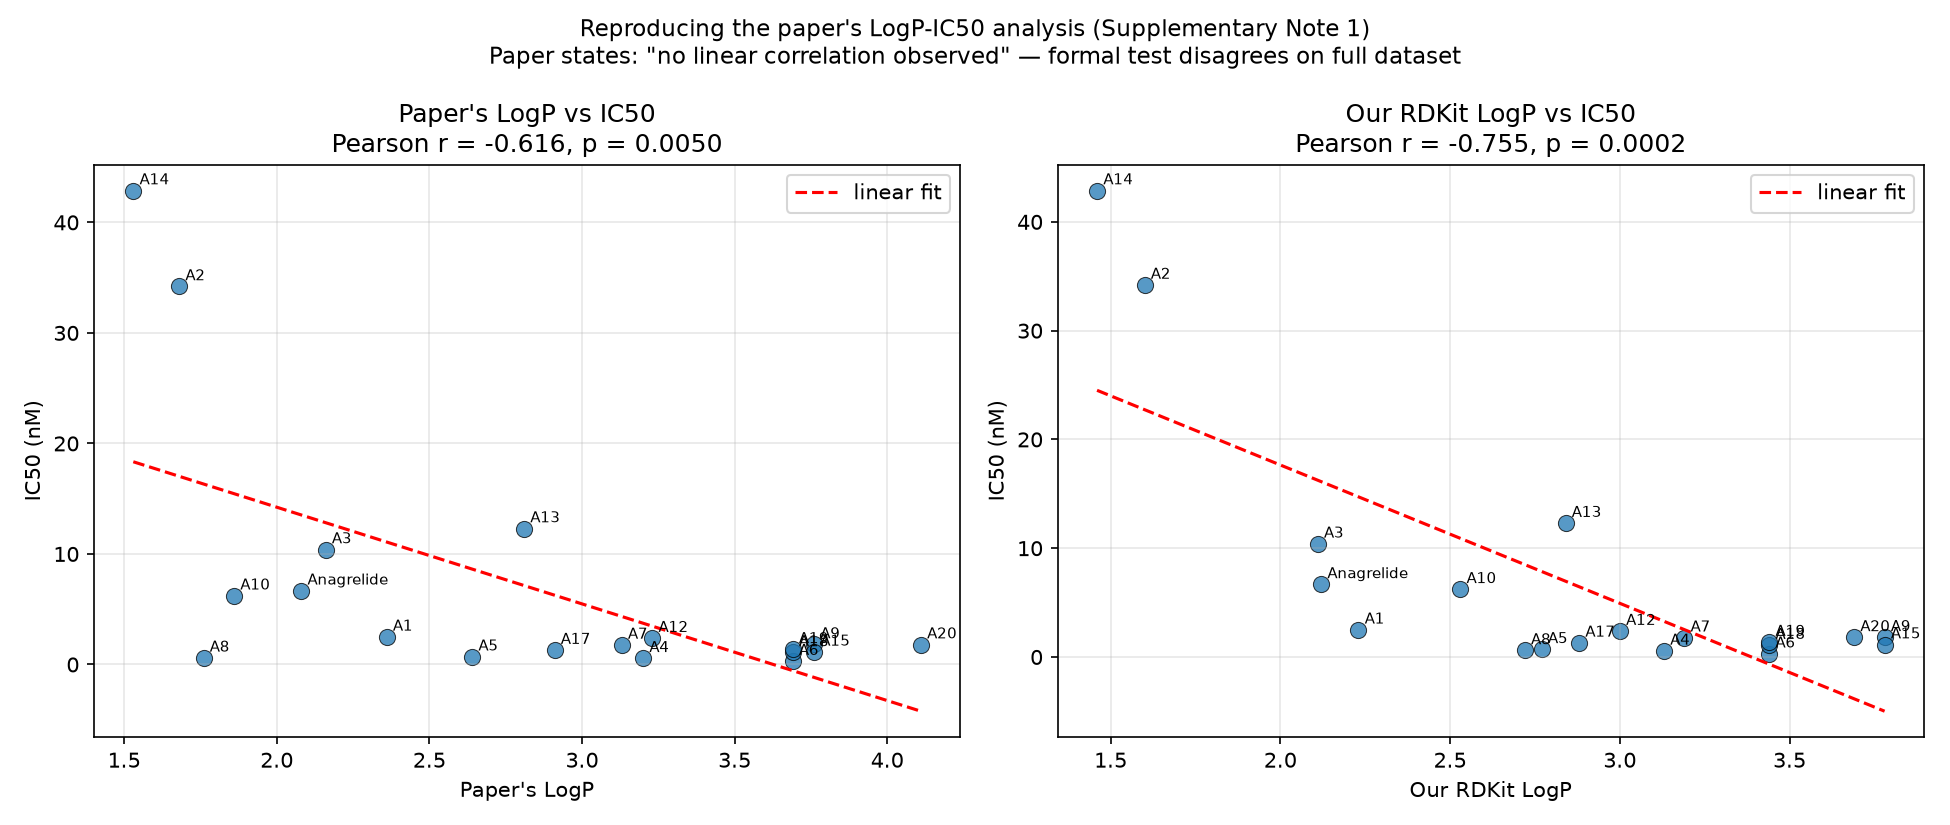

In [6]:
display(Image('../results/logp_ic50_correlation.png'))

The paper's Supplementary Note 1 states: *"We did not observe the linear
correlation of the logP value with IC50 of all the molecules."*

However, a formal Pearson correlation test on the 19 compounds with
detected IC50 shows a statistically significant negative correlation
using the paper's own LogP (r = -0.616, p = 0.005) and our independently
computed RDKit LogP (r = -0.755, p = 0.0002).

Removing two outlier compounds — **A14** (unsubstituted) and **A2** (F,
weakly hydrophobic), both with unusually high IC50 — drops the paper's
LogP correlation below significance (r = -0.454, p = 0.067), which
plausibly explains the authors' qualitative judgment, even though it
wasn't stated as an explicit outlier-exclusion analysis in the text.

## Step 4: Multi-Descriptor Analysis

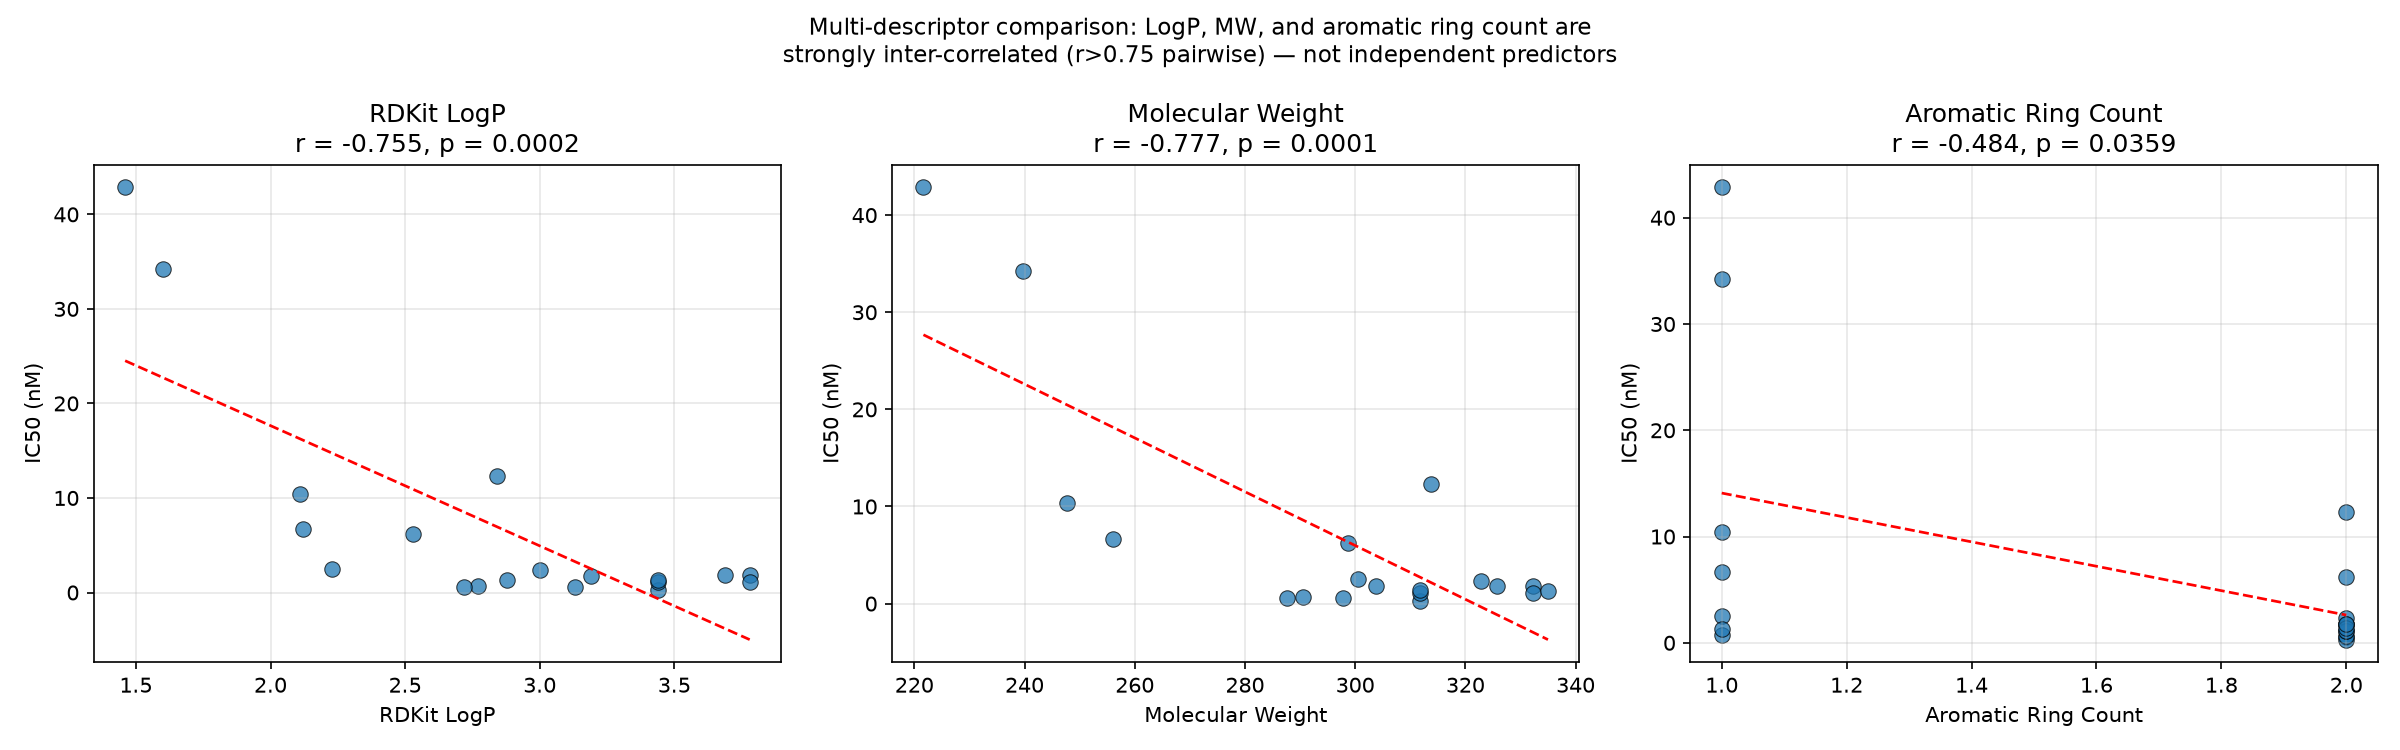

In [8]:
display(Image('../results/multi_descriptor_comparison.png'))

LogP and molecular weight are strongly inter-correlated (r = 0.879), so
combining them barely improves predictive power over either alone
(R² = 0.627 combined vs 0.604 for MW alone). TPSA and hydrogen-bonding
descriptors show no significant correlation with IC50 — substituent
**size/hydrophobicity**, not polarity, is the dominant factor driving
activity in this series.

## Step 5: Molecular Glue vs Classical PDE3A Inhibitors

In [9]:
df_classical = pd.read_csv('../data/classical_inhibitors.csv')
df_classical[['compound', 'formula', 'rdkit_logp', 'tpsa']]

,compound,formula,rdkit_logp,tpsa
0,milrinone,C12H9N3O,1.62,69.54
1,amrinone,C10H9N3O,1.02,71.77
2,enoximone,C12H12N2O2S,1.96,65.72
3,cilostazol,C20H27N5O2,3.46,81.93
4,cilostamide,C20H26N2O3,3.48,62.40
5,imazodan,C13H12N4O,1.49,59.28


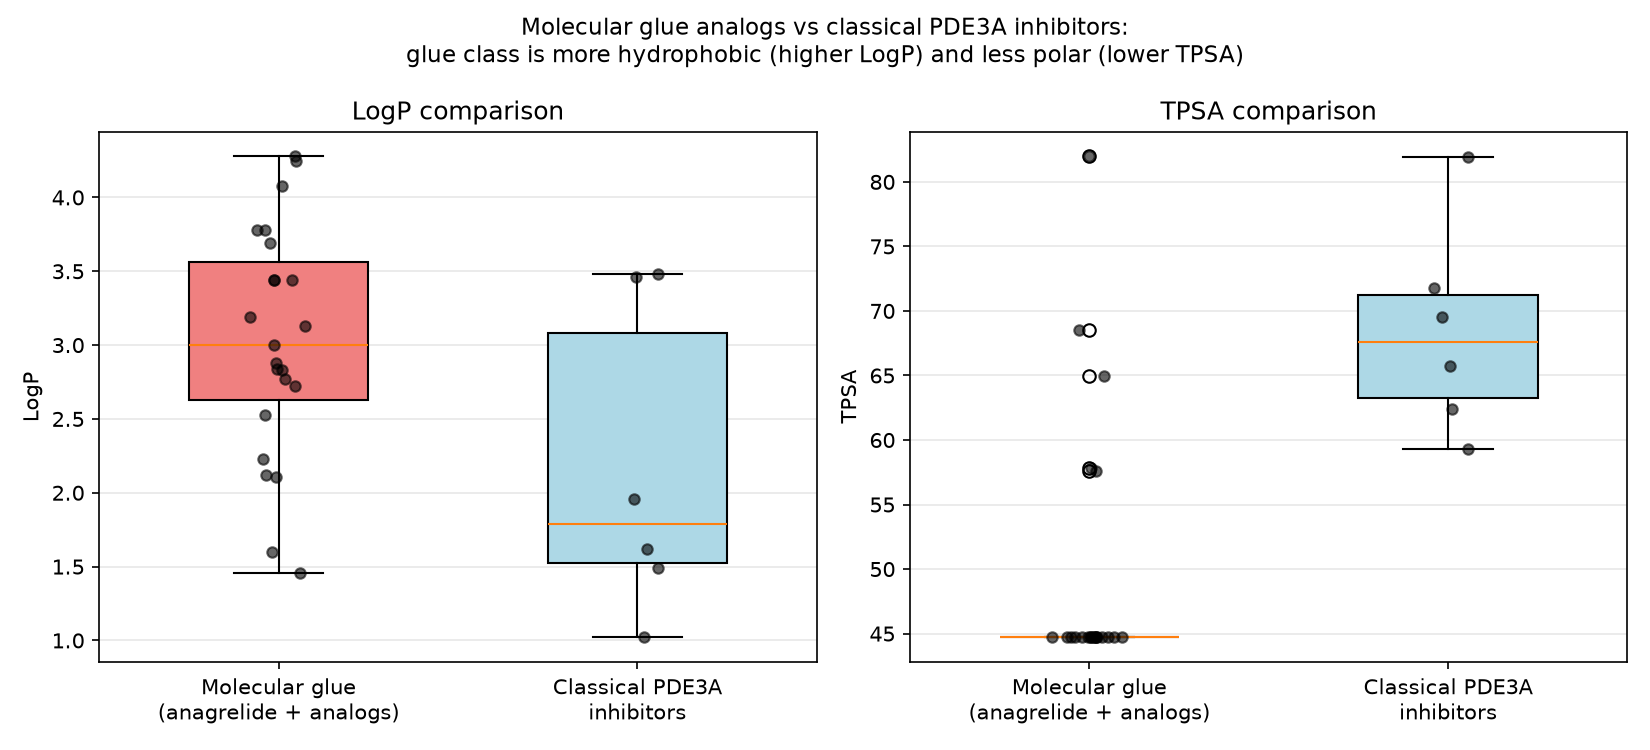

In [10]:
display(Image('../results/glue_vs_classical_comparison.png'))

Molecular glue analogs are significantly more hydrophobic (LogP: 3.03 vs
2.17, p = 0.035) and significantly less polar (TPSA: 49.4 vs 68.4,
p = 0.0002) than classical PDE3A inhibitors, with near-complete
separation on TPSA. This is consistent with the mechanistic picture from
the paper: glue compounds need a hydrophobic surface to additionally
contact SLFN12, not just occupy the PDE3A catalytic pocket.

## Conclusions

1. **Structure verification method**: All 23 molecular glue structures
   were built programmatically (RDKit RWMol atom bonding, never
   text-editing SMILES) and independently validated by comparing RDKit
   LogP against the paper's reported LogP. This process caught and
   corrected three real structural ambiguities before they could
   propagate into the final dataset — including a genuinely misread
   substituent (A18) later corrected via a higher-resolution re-check of
   the source table image.

2. **The paper's own claim doesn't fully hold up to a formal test**: a
   Pearson correlation on the full dataset is statistically significant
   (contradicting the qualitative "no correlation" statement), though the
   underlying intuition is understandable once two outlier compounds are
   examined.

3. **Substituent hydrophobicity, not polarity, drives activity**:
   LogP and molecular weight both correlate with IC50 but are redundant
   with each other; TPSA and H-bonding descriptors show no correlation at
   all in this series.

4. **Molecular glues are structurally distinguishable from classical
   PDE3A inhibitors**: significantly higher LogP and, especially, lower
   TPSA (near-complete separation), consistent with the mechanistic need
   for a hydrophobic moiety to reach across to SLFN12.

5. **Independent confirmation from real 3D structure**: measuring actual
   atomic distances in the cryo-EM structure (PDB 7EG0) confirmed the
   paper's stated H-bond network (H961, Q1001), pi-stacking (F1004), and
   hydrophobic SLFN12 contact (I557, I558) — corroborating, from a
   completely different type of evidence, the same hydrophobicity-driven
   mechanism found in the 2D descriptor comparison.

## Limitations

- The classical-inhibitor comparison group is small (n=6); statistical
  power is limited, and the t-test's p-values should be read as
  suggestive rather than conclusive.
- Four compounds (A11, A16, A21, A22) have no detected IC50 and were
  excluded from correlation analyses — this is a real assay limitation,
  not a data-cleaning choice made for convenience.
- RDKit's Crippen LogP shows systematic discrepancies (~0.6-1.0 units)
  from the paper's reported LogP specifically for nitrogen- and
  oxygen-containing heterocyclic substituents (A8/furan, A10/pyridine),
  most likely reflecting different underlying LogP algorithms rather than
  a structural error — this was checked and documented, not silently
  corrected.
- This is a retrospective structure-activity analysis of published data,
  not new experimental or computational (e.g. docking/DFT) work.